# GeoNames Place Points

Every named place in a country, with a point for each, from the GeoNames gazetteer. This is what
turns a disaster record that says "Siem Reap" into a longitude and a latitude, so it decides where
an event lands on the map.

## Provenance

These are the fields of the declaration `country_dump` builds in `climate_risk/data/geonames.py`.
One country is one archive, filed under its two-letter code, so the URL and filename carry the code
and the rest is shared. A second declaration, `COUNTRY_INFO`, fetches the table that maps alpha-3
codes onto the alpha-2 codes GeoNames files under.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.geonames import country_dump

declared = {"publisher": "GeoNames"} | dataclasses.asdict(country_dump("KH"))
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | GeoNames |
| url | https://download.geonames.org/export/dump/KH.zip |
| filename | KH.zip |
| license | CC BY 4.0 |
| citation | GeoNames geographical database, https://www.geonames.org, licensed CC BY 4.0. |
| retrieved | 2026-08-19 |

## Loading it

`load_place_points` takes an alpha-3 code and returns the country's places. The cache directory is
your choice, and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import polars as pl

import climate_risk as cr

from climate_risk.data.geonames import geonames_dir, geonames_geocoder, load_place_points, read_country_codes
from climate_risk.data.place_names import match_key
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")
COUNTRY = "KHM"

places = load_place_points(COUNTRY, cache_dir)
geocode = geonames_geocoder(COUNTRY, cache_dir)

world = cr.load_shapefile("world", cache_dir)
country = world.query("ISO_A3 == @COUNTRY")

## What you get

A polars frame with three columns. One row per distinct name key, not per place: a place published
under its own name, an ASCII form and four alternates contributes six rows, all pointing at the same
coordinate.

In [4]:
places.head()

key,lon,lat
str,f64,f64
"""phumivealthum""",105.30514,12.41753
"""krangskear""",104.33695,12.21671
"""phumileap""",103.75311,12.70305
"""lamaisondangkor""",103.8261,13.38097
"""prasatpringthom""",104.88221,13.88923


## Units

| Column | Unit |
|---|---|
| `key` | the name, lowercased with everything but letters and digits removed |
| `lon`, `lat` | degrees in EPSG:4326 |

`key` is what `match_key` produces, and it is the join surface: a written mention is keyed the same
way before it is looked up, which is how `Phnom Penh`, `phnom penh` and `Phnom-Penh` all reach one
point. The keying rules are part of the cache key, so changing them turns the table over.

## Coverage

The count is name keys rather than places, and it far exceeds the number of places the dump
carries.

In [5]:
pl.DataFrame(
    {
        "name keys": [len(places)],
        "west": [places["lon"].min()],
        "east": [places["lon"].max()],
        "south": [places["lat"].min()],
        "north": [places["lat"].max()],
        "Phnom Penh": [str(geocode(COUNTRY, "Phnom Penh"))],
    }
)

name keys,west,east,south,north,Phnom Penh
i64,f64,f64,f64,f64,str
37713,102.31667,107.5768,9.77572,14.64504,"""(104.91394, 11.57489)"""


## A plot

Where the geocoder puts a provincial capital. The dump carries a feature class the loader drops,
and a province and its capital city usually share a name. The tie-break keeps the most populous
place, a province always outnumbers the city inside it, so the name resolves to the province's
nominal center and the arrow is how far that sits from the city itself.

In [6]:
# The loader keeps key, lon and lat. The feature class it drops is what this figure needs, so the
# dump is read again here: A is an administrative area, P a populated place.
FIELDS = {1: "name", 4: "lat", 5: "lon", 6: "feature_class", 7: "feature_code", 14: "population"}

# GeoNames files a dump under the two-letter code, which is what the country table maps onto.
alpha2 = read_country_codes(cache_dir)[COUNTRY]

with ZipFile(geonames_dir(cache_dir) / f"{alpha2}.zip") as archive, archive.open(f"{alpha2}.txt") as dump:
    rows = pl.read_csv(
        dump.read(),
        separator="\t",
        has_header=False,
        quote_char=None,
        columns=list(FIELDS),
        new_columns=list(FIELDS.values()),
        schema_overrides={"lat": pl.Float64, "lon": pl.Float64, "population": pl.Int64},
        infer_schema_length=0,
    )

In [7]:
keyed = rows.with_columns(pl.col("name").map_elements(match_key, return_dtype=pl.String).alias("key"))
capitals = keyed.filter(pl.col("feature_code").is_in(["PPLA", "PPLC"]))

resolved = [geocode(COUNTRY, key) for key in capitals["key"]]
located = capitals.with_columns(
    pl.Series("to_lon", [point[0] for point in resolved]),
    pl.Series("to_lat", [point[1] for point in resolved]),
)

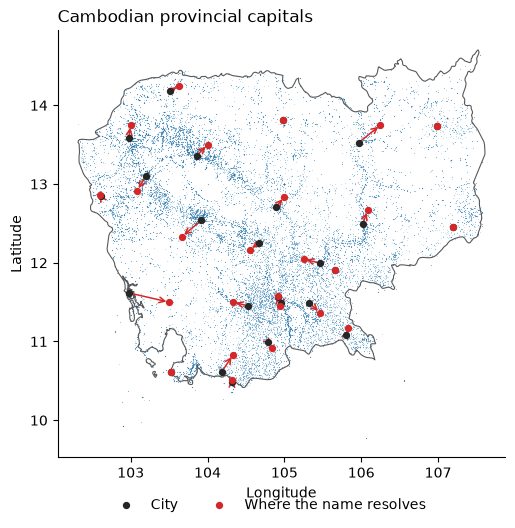

In [8]:
figure, axis = plt.subplots(figsize=(5.5, 5.0))
country.boundary.plot(ax=axis, color=PALETTE["divider"], lw=0.8)
axis.scatter(places["lon"], places["lat"], s=0.6, color=PALETTE["primary"], alpha=0.25, lw=0)

for row in located.iter_rows(named=True):
    axis.annotate(
        "",
        xy=(row["to_lon"], row["to_lat"]),
        xytext=(row["lon"], row["lat"]),
        arrowprops={"arrowstyle": "->", "color": PALETTE["secondary"], "lw": 1.1},
    )

axis.scatter(located["lon"], located["lat"], s=18, color=PALETTE["observed"], zorder=3, label="City")
axis.scatter(
    located["to_lon"], located["to_lat"], s=18, color=PALETTE["secondary"], zorder=3, label="Where the name resolves"
)

axis.set_title("Cambodian provincial capitals", loc="left")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(False)

handles, labels = axis.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.04), ncol=2, frameon=False)

plt.show()

## Gotchas

*A province beats the city inside it.* The tie-break keeps the most populous place holding a name,
and an ADM1 province always has more people than its capital. Seventeen of Cambodia's twenty-five
provincial capitals therefore resolve to the province's nominal center, a median of 21 km from the
city and 58 km in the worst case. On the 25 km grid the exposure page builds, that is a cell or
more.

*A row is a name, not a place.* Cambodia has about 15,000 places and this table has 37,713 rows,
because every alternate spelling gets its own. Counting rows counts spellings.

*The key is lossy on purpose.* `match_key` strips everything but letters and digits and lowercases
the rest, so two genuinely different places whose names differ only in punctuation collapse onto
one key, and the more populous one takes it.

*The dump is per country and so is the cache entry.* `iso` is part of the key, so asking for a
second country downloads and builds a second table rather than widening the first.

*The geocoder answers `None` rather than raising.* A name that keys to nothing returns no point, and
a caller that does not check gets a silent gap rather than an error.